# Pushover Analysis on MDOF Stick Model

## Introduction

This Jupyter Notebook outlines a structured workflow for conducting pushover analysis on multi-degree-of-freedom (MDOF) structural models using OpenSees. Pushover analysis is a static, nonlinear procedure that helps assess the inelastic behavior and capacity of structures under increasing lateral loads, simulating the effects of seismic demand in a simplified manner. Unlike time-history analysis, which uses dynamic input, pushover analysis incrementally applies lateral forces or displacements to assess structural response and identify limit states.

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDoF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration) based on the methodology of Lu et al. (2020) and other modifications to account for distinct response typologies (i.e., bilinear, trilinear, and quadrilinear backbone definitions)

2. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including mass, height, fundamental period, and the nonlinear behavior at each degree of freedom, including plastic hinges or other inelastic mechanisms

3. **Run Static (Monotonic) Pushover Analysis in OpenSees**: Apply a monotonically increasing lateral load (typically using a predefined force or displacement pattern such as inverted triangular or uniform) until structural collapse or a target displacement is reached. Extract key response metrics such as base shear vs. roof displacement/maximum interstorey drift curves (capacity curves)

4. **Run Cyclic Pushover Analysis in OpenSees**: Apply cyclic loading protocols to assess structural degradation, stiffness deterioration, and strength loss under repeated loading. This allows for evaluation of energy dissipation capacity, hysteretic response, etc.

## Initialize Libraries ##

In [1]:
import numpy as np

from openquake.vmtk.units import units
from openquake.vmtk.modeller import modeller

## Calibrate and Compile the Stick Model ##

Below is a list of required input parameters associated with the single-degree-of-freedom oscillator if an SDOF-to-MDOF calibration is required.

In [2]:
# Number of storeys
number_storeys = 3

# Relative floor heights list
floor_heights = [2.80, 3.00, 3.00]

# Relative floor masses list
floor_masses = [0.75, 0.75, 0.75]  # Unit mass for SDOFs

# MDOF capacity: 3 storeys × 4 points each (quadrilinear definition)
storey_drifts = np.array(
    [[0.008, 0.015, 0.025, 0.050],    # storey 1 drift capacity: Brittle failure at ~1.5% drift
     [0.010, 0.018, 0.028, 0.055],    # storey 2 drift capacity
     [0.012, 0.022, 0.032, 0.060]])   # storey 3 drift capacity


storey_forces = np.array(
    [[3.5, 5.0, 1.5, 1.5],            # storey 1 shear force: Sharp drop from 10kN to 3kN
     [4.0, 5.5, 1.7, 1.7],            # storey 2 shear force
     [4.5, 6.5, 2.0, 2.0]]) * units.kN  # storey 3 shear force


# Flag to activate default stiffness-strength degradation and pinching4
mdof_degradation = True

## Setting Up, Running and Exporting Static (Monotonic) Pushover Analysis ##

`do_spo_analysis` runs a displacement-controlled static pushover by incrementally applying a lateral load pattern (`phi`) up to a target displacement of `ref_disp × disp_scale_factor`. It returns a results dictionary containing floor displacements (`spo_disps`), base shear (`spo_rxn`), spring deformations and forces, and inter-storey drift ratio histories. When `save_animation_path` is provided, a synchronised three-panel animation (deformed shape, pushover curve, base shear vs. MIDR) is exported alongside the results.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 3, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 3, which is greater than the tolerance


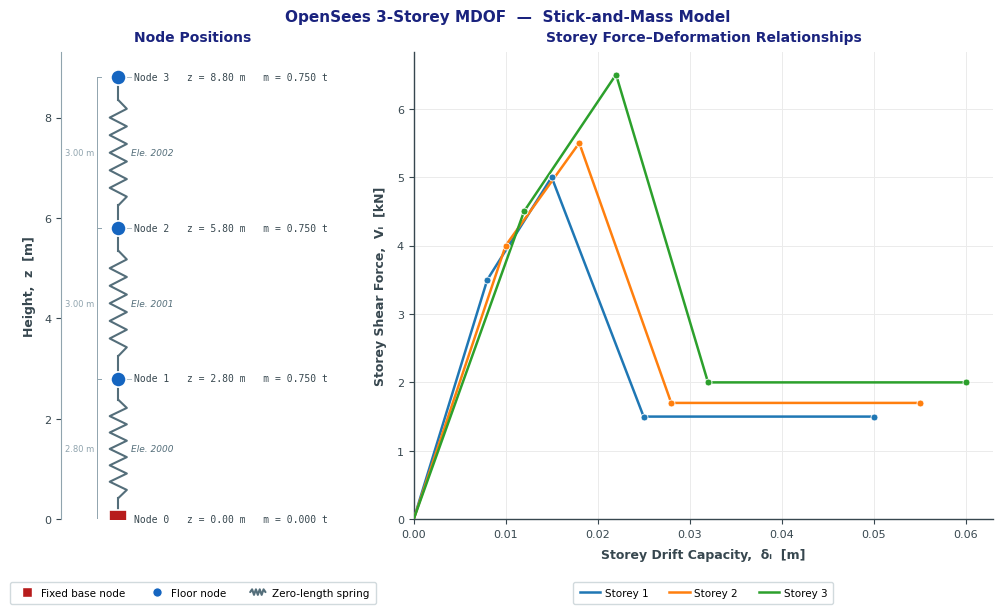

~~~~~~~ ANALYSIS SUCCESSFUL! ~~~~~~~~~
Stopped because of load factor below zero
Saving SPO animation (30 frames) to: out/spo_animation.gif
ANALYSIS COMPLETED!


In [3]:
# Compile the MDOF model
model = modeller(number_storeys,
                 floor_heights,
                 floor_masses,
                 storey_drifts,
                 storey_forces,
                 # No need to multiply by g since the units are already in kN
                 mdof_degradation)         # Initialise the class (Build the model)
model.compile_model()                      # Compile the MDOF model

# View the model
model.plot_model()                         # Visualise the model

# Do gravity analysis
model.do_gravity_analysis()                # Do gravity analysis

# Do modal analysis
T, phi = model.do_modal_analysis(num_modes=number_storeys,
                                 plot_modes=False)   # Do modal analysis and get period of vibration

# Define pushover analysis parameters
ref_disp = 0.005                 # Reference displacement
disp_scale_factor = 15           # Multiplier of the reference displacement
push_dir = 1                     # Push direction (for X-direction:1, for Y-direction=2)
# Load pattern (In this example, we apply a user-defined triangular pattern)
phi = [0.33, 0.66, 1.00]

# Do pushover analysis
results = model.do_spo_analysis(
    ref_disp,
    disp_scale_factor,
    push_dir,
    phi,
    pFlag=False,
    num_steps=200,
    ansys_soe='BandGeneral',
    constraints_handler='Transformation',
    numberer='RCM',
    test_type='EnergyIncr',
    init_tol=1.0e-5,
    init_iter=1000,
    algorithm_type='KrylovNewton',
    # Export animation of SPO when setting path, set to None if you opt not to
    save_animation_path='out/spo_animation.gif')

print('ANALYSIS COMPLETED!')

## Explore the Results of the Static Pushover Analysis ##

In [4]:
# Unpack the SPO results
spo_disps = results['spo_disps']          # Displacements at each control node (i.e., floor)
spo_rxn = results['spo_rxn']            # Reaction at base (Base shear)
# Displacements in nonlinear springs (i.e., zero-length elements)
spo_disps_spring = results['spo_disps_spring']
# Forces in nonlinear springs (i.e., zero-length elements)
spo_forces_spring = results['spo_forces_spring']
spo_idr = results['spo_idr']            # Interstorey drift ratios
spo_midr = results['spo_midr']           # Maximum interstorey drifts

![spo_animation](out/spo_animation.gif)

## Setting Up, Running and Exporting Cyclic Pushover Analysis ##

`do_cpo_analysis` drives the model through a sequence of positive–negative ductility cycles defined by `mu_levels × ref_disp`, recording the full hysteretic response at each step. It returns floor displacements (`cpo_disps`), base shear (`cpo_rxn`), inter-storey drift ratios, and cumulative dissipated energy. When `save_animation_path` is provided, a four-panel animation (deformed shape, hysteretic curve, base shear vs. MIDR, cumulative energy) is exported alongside the results.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 3, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 3, which is greater than the tolerance


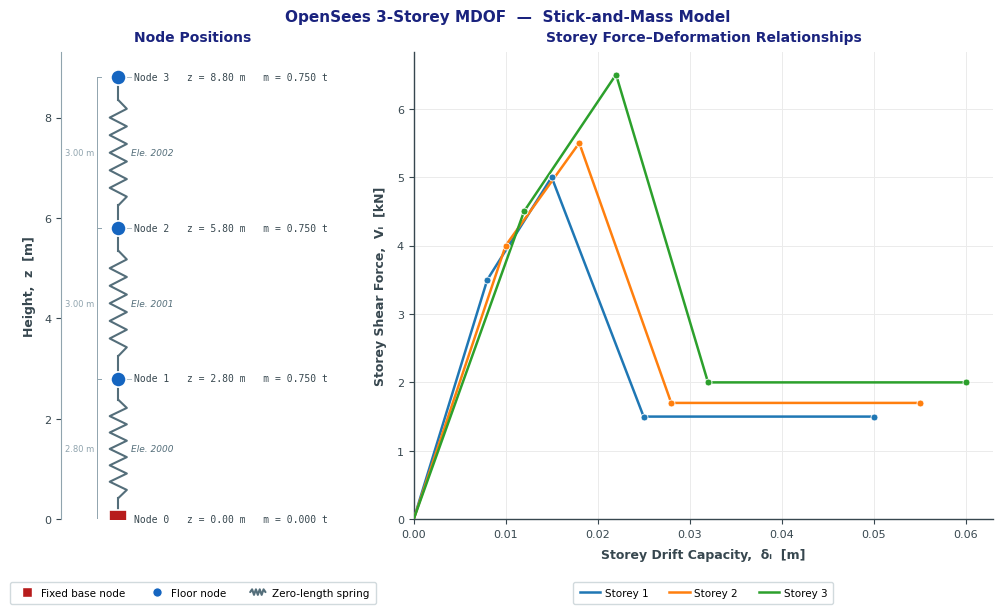


Saving animation to: out/cpo_animation.gif
ANALYSIS COMPLETED!


In [5]:
# Compile the MDOF model
model = modeller(number_storeys,
                 floor_heights,
                 floor_masses,
                 storey_drifts,
                 storey_forces,
                 mdof_degradation)         # Initialise the class (Build the model)
model.compile_model()                      # Compile the MDOF model

# View the model
model.plot_model()                         # Visualise the model

# Do gravity analysis
model.do_gravity_analysis()                # Do gravity analysis

# Do modal analysis
T, phi = model.do_modal_analysis(num_modes=number_storeys,
                                 plot_modes=False)   # Do modal analysis and get period of vibration

# Define pushover analysis parameters
ref_disp = 0.012                                       # Reference displacement
mu_levels = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 10]   # Target ductility factor
# The number of displacement increments for each loading cycle
dispIncr = 10
max_step = ref_disp * 0.05                 # No step larger than 5% of yield displacement
# Load pattern (In this example, we apply a user-defined triangular pattern)
phi = [0.33, 0.66, 1.00]

# Do pushover analysis
results = model.do_cpo_analysis(
    ref_disp,
    mu_levels,
    push_dir,
    dispIncr,
    phi,
    max_step=max_step,
    pFlag=False,
    ansys_soe='BandGeneral',
    constraints_handler='Transformation',
    numberer='RCM',
    test_type='NormDispIncr',
    init_tol=1.0e-5,
    init_iter=1000,
    algorithm_type='KrylovNewton',
    # Export animation of CPO when setting path, set to None if you opt not to
    save_animation_path='out/cpo_animation.gif')

print('ANALYSIS COMPLETED!')

## Explore the Results of the Cyclic Pushover Analysis ## 

In [6]:
# Unpack results
cpo_disps = results['cpo_disps']  # Displacements at each control node (i.e., floor)
cpo_rxn = results['cpo_rxn']    # Reaction at base (Base shear)
cpo_energy = results['cpo_energy']  # Cumulative Dissipated Energy

![cpo_animation](out/cpo_animation.gif)